<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
import serial

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path

from datetime import datetime
import json

c:\Users\hlab_\anaconda3\envs\qickdawg_jeree\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to Laser and Board</h2>
</div>

In [2]:
qd.start_client('10.225.208.77')
ser_laser = serial.Serial(
    port='COM3',
    baudrate=9600,
    stopbits=1,
    bytesize=8,
    parity='N',
    xonxoff=True)

ser_laser.write(b'*ON\r')
ser_laser.write(b'LAS\r')

4

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Laser Functions</h2>
</div>

In [3]:
def On():
    qd.laser_on(default_config)
    
def Off():
    SetPower(0)

def SetPower(power):
    command = f'PWR{power}\r'.encode()
    ser_laser.write(command)

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Setup Saving</h2>
</div>

In [4]:
# Parent directory where all measurement data is saved
parent_save_dir = Path(r"Z:\Data\DefectMsmts\Data\Albania")

# Create it if it doesn't already exist (safe to run even if it does)
parent_save_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {parent_save_dir}")
print(f"Exists: {parent_save_dir.exists()}")

Saving to: Z:\Data\DefectMsmts\Data\Albania
Exists: True


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Save Functions</h3>
</div>

In [5]:
def create_experiment_folder(subfolder_name, parent_dir=parent_save_dir):
    """
    Creates a new timestamped, numbered experiment folder inside
    parent_dir/subfolder_name, and returns the Path to it.
    """
    subfolder_path = parent_dir / subfolder_name
    subfolder_path.mkdir(parents=True, exist_ok=True)

    # Count existing experiment folders to figure out the next experiment number
    existing_experiments = [p for p in subfolder_path.iterdir() if p.is_dir()]
    experiment_number = len(existing_experiments) + 1

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    experiment_folder = subfolder_path / f"{timestamp}_{experiment_number:03d}"
    experiment_folder.mkdir(parents=True, exist_ok=False)

    return experiment_folder

def save_metadata(run_folder, params: dict, filename="metadata.json"):
    with open(run_folder / filename, "w") as f:
        json.dump(params, f, indent=4)

# Table of Contents
0. [Assgin default configurations for pulsing](#first-bullet)<br>
    a. The NVConfiguration object<br>
    b. A note about NVConfiguration<br>
1. [Turning your laser On and Off](#second-bullet) <br>
    a. Turn Your Laser On <br>
    b. Turn Your Laser Off <br>
2. [Photoluminescence (PL) Intensity](#third-bullet)<br>
    a. Plotting the Sequence <br>
    b. Configuration and Getting a Single Data Point of PL intensity<br>
    c. Plotting the Sequence with Attribute Values<br>
    d. PL Intensitiy Live<br>
3. [Optically Deteceted Magnetic Resonance (ODMR) Spectrum](#fourth-bullet)<br>
    a. Configuration, Measurment and Plotting<br>
    b. Live plot ODMR spectrum<br>
    c. Print the Assembly Language<br>
4. [Get the Readout Window](#fifth-bullet)<br>
    a. Configuration, Measurement, and Plotting<br>
    b. Fitting the Readout Window
5. [Rabi Oscillations](#seventh-bullet) <br>
    a. Configuration, Measurement, and Plotting <br>
    b. Fitting Rabi Oscillations <br>
    c. Live Rabi Oscillations <br>
6. [Ramsey](#sixth-bullet)<br>
    a. Configuration, Measurement, and Plotting<br>
    b. ODMR spectrum from Ramsey <br>
7. [Hahn Echo Delay Sweep](#eigth-bullet)<br>
    a. Configurations <br>
    b. Fitting Hahn Echo Decay, Getting T<sub>2 Hahn</sub><br>
8. [T<sub>1</sub> Delay Sweep](#nineth-bullet)<br>
    a. Configuration<br>
    b. Fitting T1 Decay, Getting T<sub>1</sub><br>

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">0. Assigning Default Configurations for Pulsing: NVConfiguration</h2>
</div>
<a class="anchor" id="first-bullet"></a>

In [6]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 1
default_config.edge_counting = True

# Hysteresis thresholds prevent double-counting from noise: signal must rise above high_threshold to register a photon, then fall below low_threshold before it can register the next one
default_config.high_threshold = 8000
default_config.low_threshold = 500


default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0
default_config.adc_trigger_pmod = 1

default_config.readout_integration_tus = 3
default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom


Run ALL Above Here For Initialization



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">1. Turn Laser On and Off</h2>
</div>
<a class="anchor" id="first-bullet"></a>


In [9]:
SetPower(0)

In [8]:
Off()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> See Raw ADC Signal</h3>
</div>

In [9]:
SetPower(0)

In [10]:
# default_config.readout_integration_tus = 3 #max given apd buffer is 3.3
# data = qd.check_readout(default_config, readout_integration_treg=default_config.readout_integration_treg)
# time_us = np.linspace(0, default_config.readout_integration_tus, len(data))
# plt.plot(time_us, data)
# plt.xlabel("Time (µs)")
# plt.ylabel("ADC signal")


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">2. Photoluminescence (PL) Intensity</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  2d. PL Intensity Live</h3>
</div>



In [14]:
# SetPower(10)

In [15]:
# SetPower(20)
# config = copy(default_config)

# config.readout_integration_treg = 2**14 # Maxium number of integrated points
# config.reps = 500

# prog = qd.PLIntensity(config) 

# def get_cps():

#     d = prog.acquire(progress=False)

#     return d / qd.max_int_time_treg / qd.min_time_tns * 1e9


# qd.live_plot(get_cps)

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Dark Counts </h3>
</div>

In [11]:
# SetPower(1)

In [17]:
# config = copy(default_config)

# config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
# config.reps = 10

# prog = qd.DarkCounts(config) 
# counts = prog.acquire()

# print('{} dark counts'.format(counts))
# print('{} dark cps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9 / config.reps))
# print('{} dark Mcps'.format(counts / qd.max_int_time_treg / qd.min_time_tns * 1e9 / 1e6 / config.reps))



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">3 Optically Detected Magnetic Resonance Spectrum</h2>
</div>

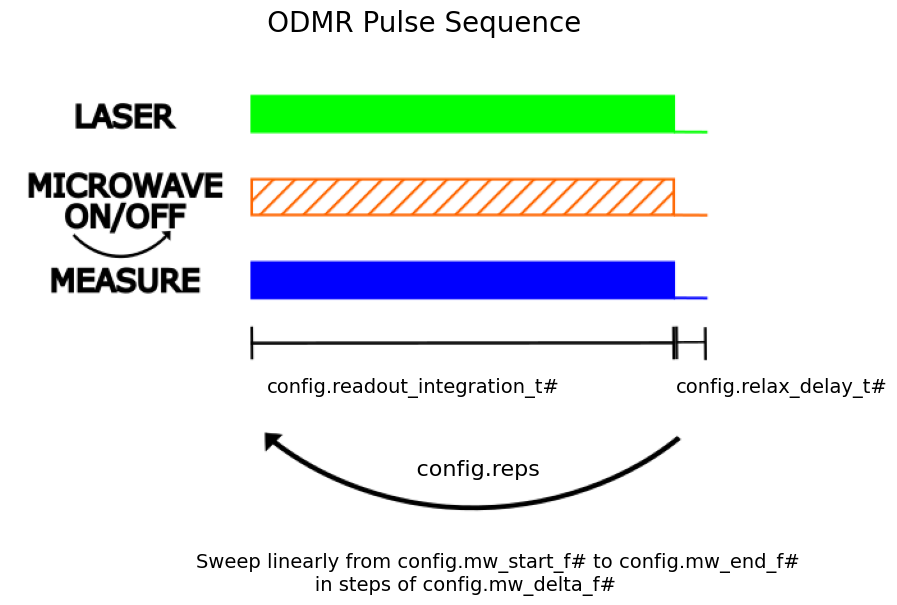

In [18]:
qd.LockinODMR.plot_sequence()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Time Estimate </h3>
</div>

In [19]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 40
mw_gain = 15000
reps = 100000
relax_delay_treg = 500
sweep_start_fGHz = 3
sweep_stop_fGHz = 4
sweep_step_fGHz = 0.01
nd_filter_OD = 0

config.readout_integration_tus = qd.max_int_time_tus
config.mw_gain = mw_gain
config.pre_init = True
config.reps = reps
config.relax_delay_treg = relax_delay_treg

config.add_linear_sweep('mw', 'fGHz', start=sweep_start_fGHz, stop=sweep_stop_fGHz, delta=sweep_step_fGHz)

# ---- Estimate runtime (no hardware call yet) ----
prog = qd.LockinODMR(config)
est_seconds = prog.total_time()
print(f"Estimated runtime: {est_seconds/60:.1f} min")


Requested 3 to 4 by 0.01
Instead using 3.0 to 3.9999999618530273 by 0.009999999618530273 in 101 steps
Estimated runtime: 72.4 min


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  3a. Run ODMR </h3>
</div>


In [8]:
SetPower(0)


Requested 3 to 4 by 0.01
Instead using 3.0 to 3.9999999618530273 by 0.009999999618530273 in 101 steps


100%|██████████| 101000/101000 [00:43<00:00, 2325.69it/s]


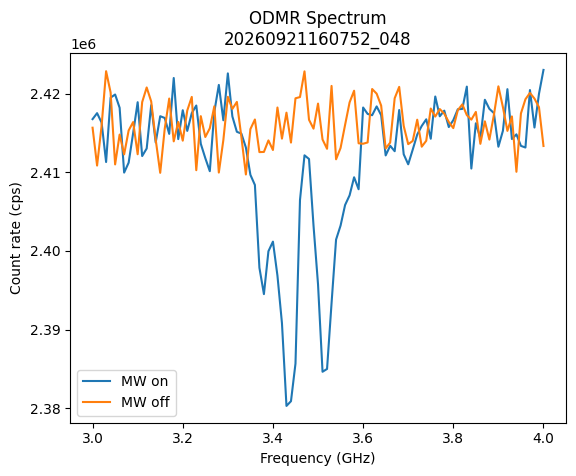

Experiment saved to: Z:\Data\DefectMsmts\Data\Albania\ODMR\20260921160752_048


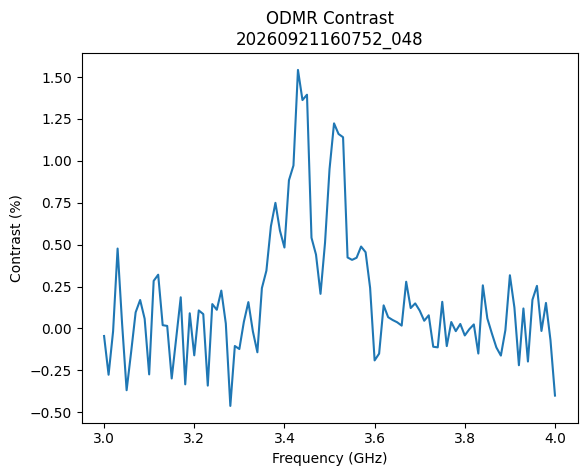

In [7]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 60       # LP
mw_gain =2000 # MW gain
reps = 1000
relax_delay_treg = 500
sweep_start_fGHz = 3
sweep_stop_fGHz = 4
sweep_step_fGHz = 0.01
nd_filter_OD = 0.5

# ---- Setup ----
SetPower(laser_power)

config.readout_integration_tus = qd.max_int_time_tus
config.mw_gain = mw_gain
config.pre_init = True
config.reps = reps
config.relax_delay_treg = relax_delay_treg

config.add_linear_sweep('mw', 'fGHz', start=sweep_start_fGHz, stop=sweep_stop_fGHz, delta=sweep_step_fGHz)

# ---- Run ----
prog = qd.LockinODMR(config)
odmr = prog.acquire(progress=True)

Off()

#SAVING
experiment_folder = create_experiment_folder("ODMR")
experiment_id = experiment_folder.name  # e.g. "2026-07-06_150405_001"

# ---- Metadata ----
params = {
    "experiment_id": experiment_id,
    "timestamp": datetime.now().isoformat(),
    "laser_power": laser_power,
    "mw_gain": mw_gain,
    "reps": reps,
    "ND Filter OD": nd_filter_OD,
    "relax_delay_treg": relax_delay_treg,
    "sweep_start_fGHz": sweep_start_fGHz,
    "sweep_stop_fGHz": sweep_stop_fGHz,
    "sweep_step_fGHz": sweep_step_fGHz,
}
save_metadata(experiment_folder, params)

# ---- Derived data ----
contrast = (odmr.reference - odmr.signal) / odmr.reference * 100

# ---- Raw + derived data (npz: fast, Python-native) ----
np.savez(
    experiment_folder / "odmr_data.npz",
    frequencies=odmr.frequencies,
    signal=odmr.signal,
    reference=odmr.reference,
    contrast=contrast,
)

# ---- Raw + derived data (csv) ----
np.savetxt(
    experiment_folder / "odmr_data.csv",
    np.column_stack([odmr.frequencies, odmr.signal, odmr.reference, contrast]),
    delimiter=",",
    header="frequency_kHz,signal,reference,contrast_pct",
    comments=""
)

# ---- Plot ----
exposure_time_s = config.reps * config.readout_integration_tus * 1e-6
signal_cps = odmr.signal / exposure_time_s
reference_cps = odmr.reference / exposure_time_s

fig, ax = plt.subplots()
ax.plot(odmr.frequencies/1000, signal_cps, label="MW on")
ax.plot(odmr.frequencies/1000, reference_cps, label="MW off")
ax.set_title(f"ODMR Spectrum\n{experiment_id}")
ax.set_ylabel("Count rate (cps)")
ax.set_xlabel("Frequency (GHz)")
ax.legend()

fig.savefig(experiment_folder / "odmr_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Contrast plot ----
fig2, ax2 = plt.subplots()
ax2.plot(odmr.frequencies/1000, contrast)
ax2.set_title(f"ODMR Contrast\n{experiment_id}")
ax2.set_ylabel("Contrast (%)")
ax2.set_xlabel("Frequency (GHz)")

fig2.savefig(experiment_folder / "odmr_contrast.png", dpi=300, bbox_inches="tight")
# plt.show()

print(f"Experiment saved to: {experiment_folder}")

#### Find Resonance

In [8]:
peaks, properties = find_peaks(contrast, prominence=1)  # tune prominence if it finds too many/few
peak_freqs = odmr.frequencies[peaks]
peak_heights = contrast[peaks]

print("Found dips (MHz, contrast %):")
for f, h in zip(peak_freqs, peak_heights):
    print(f"  {f:.1f} MHz -> {h:.2f}%")

best_idx = peaks[np.argmax(peak_heights)]
resonance_fMHz = odmr.frequencies[best_idx]
print(f"\nStrongest resonance: {resonance_fMHz:.1f} MHz")

Found dips (MHz, contrast %):
  3430.0 MHz -> 1.54%
  3510.0 MHz -> 1.22%

Strongest resonance: 3430.0 MHz


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Looping ODMR</h3>
</div>


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> 4. Calibrate the Readout Window</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  4a. Configuration, Measurement, Plotting, and Fitting </h3>
</div>
The readout window pulse sequence requires the following new configuration attributes in addition to the default configuration:

- .mw_pi2_t# - approximate pi/2 pulse, used to give spin contrast in the readout window. 
- .mw_f# - pulsing frequency for the microwave channel

- .readout_length_t# - length of time series readout, tyipcally 1020 reg
- .laser_initialize_t# - total time for the laser to be on and should be sufficiently long to initilze spins to ms=0
- .mw_readout_delay_t# - buffer time between the end of the microwave pulse and the beginning of the readout, a few 100 ns is typically sufficient and depends on the experimental setup
- .laser_readout_offset_t# - time between the trigger of the laser and the beginning of the readout, as seen by the adc (to be calibrated in this sequence, initially set to 0)
- .soft_avgs - number of repititions to average over
- .reps = 1, time domain data can only be taken on rep at a time if the total readout length is 1020 points
- .pre_init = True, is extremely important for this sequence because the time between soft averages is sufficiently long that there is appreciable T1 relaxation and spins must be reinitialized before pulsing


In [35]:
resonance_fMHz=3430

In [16]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 30      
floor_treg = 200      # avoid the ADC/laser pipeline artifact (~135-150 cycles), stay clear of it
n_steps = 185

# ---- Setup ----
SetPower(laser_power)

config.mw_gain = 5000         
config.mw_fMHz = resonance_fMHz
config.mw_pi2_tns = 100

config.pre_init = True
config.relax_delay_tus = 0.5

config.laser_on_tus = 15
config.readout_integration_tns = 50
config.readout_reference_start_tus = 10

config.mw_readout_delay_treg = 35
config.reps = 1000

for i in range(n_steps):

    config.laser_readout_offset_treg = floor_treg + i * config.readout_integration_treg

    prog = qd.IntegratedReadoutWindow(config)
    d = prog.acquire()

    if i == 0:
        results = d
        results.delay = np.array([config.laser_readout_offset_treg])
    else:
        for key in d.keys():
            results[key] = np.append(results[key], d[key])
        results.delay = np.append(results.delay, [config.laser_readout_offset_treg])

Off()

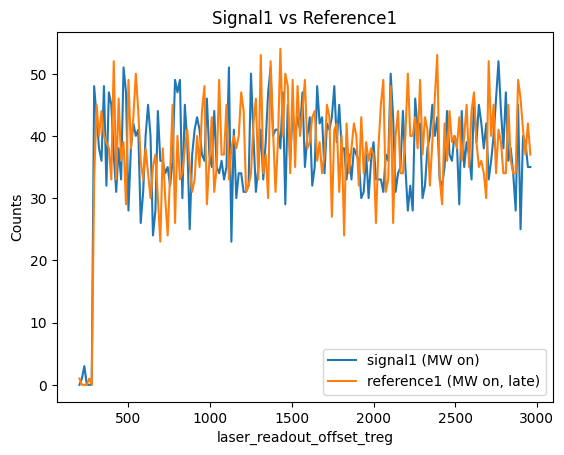

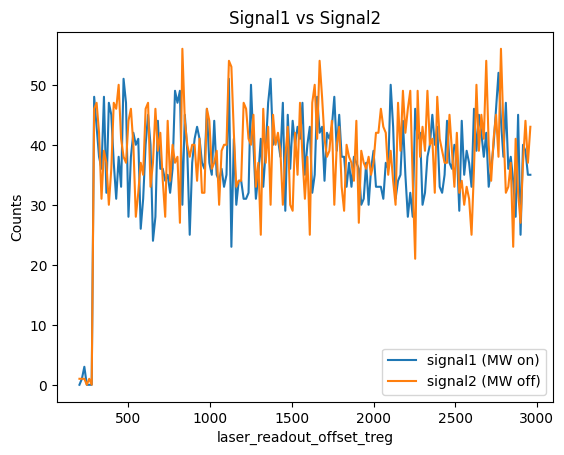

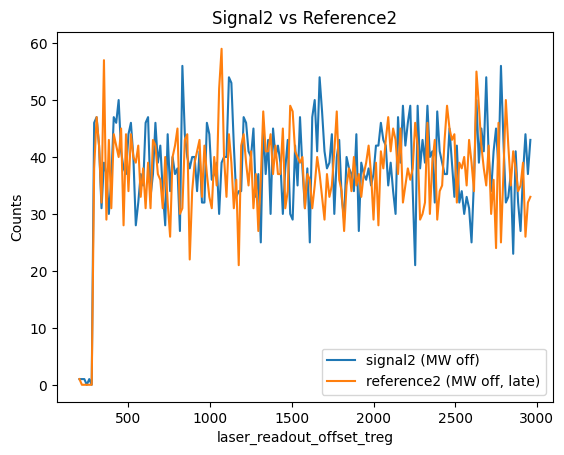

In [17]:
x = results.delay

# 1) signal1 vs reference1
plt.plot(x, results.signal1, label='signal1 (MW on)')
plt.plot(x, results.reference1, label='reference1 (MW on, late)')
plt.xlabel('laser_readout_offset_treg')
plt.ylabel('Counts')
plt.title('Signal1 vs Reference1')
plt.legend()
plt.show()

# 2) signal1 vs signal2
plt.plot(x, results.signal1, label='signal1 (MW on)')
plt.plot(x, results.signal2, label='signal2 (MW off)')
plt.xlabel('laser_readout_offset_treg')
plt.ylabel('Counts')
plt.title('Signal1 vs Signal2')
plt.legend()
plt.show()

# 3) signal2 vs reference2
plt.plot(x, results.signal2, label='signal2 (MW off)')
plt.plot(x, results.reference2, label='reference2 (MW off, late)')
plt.xlabel('laser_readout_offset_treg')
plt.ylabel('Counts')
plt.title('Signal2 vs Reference2')
plt.legend()
plt.show()

In [13]:
# config = copy(default_config)

# config.mw_gain = 30000
# config.mw_fMHz = 2768
# config.mw_pi2_tus = 100

# config.pre_init=True

# config.relax_delay_tus=0.5

# config.laser_on_tus = 15 # in us
# config.readout_integration_tns = 100  # us
# config.readout_reference_start_tus = 10 # us

# config.mw_readout_delay_treg = 35

# config.reps=5000

# for i in range(20):

#     config.laser_readout_offset_treg = i * config.readout_integration_treg + 150

#     prog = qd.IntegratedReadoutWindow(config)

#     d = prog.acquire()

#     if i ==0:
#         results = d
#         results.delay = np.array([config.laser_readout_offset_treg])
#     else:
#         for key in d.keys():
#             results[key] = np.append(results[key], d[key])
#         results.delay = np.append(results.delay, [config.laser_readout_offset_treg])

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  4b Fitting the Readout Window Data </h3>
</div>



In [ ]:
plt.plot(results.delay * qd.min_time_tus, results.signal1)
plt.plot(results.delay * qd.min_time_tus, results.signal2)

In [ ]:
data_off = results.signal2
data_on = results.signal1

x = (data_off-data_on)
t = np.array(results.delay) * qd.min_time_tus

plt.plot(t, x, linewidth=4, color='red')

param, _ = curve_fit(qd.exponential_decay, t, x, p0=[800, 0.8, 100])

plt.plot(t, qd.exponential_decay(t, *param), linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
# plt.xlim(0, )
# plt.ylim(0, )
print(param)


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> 5 Rabi Oscillations</h2>
</div>


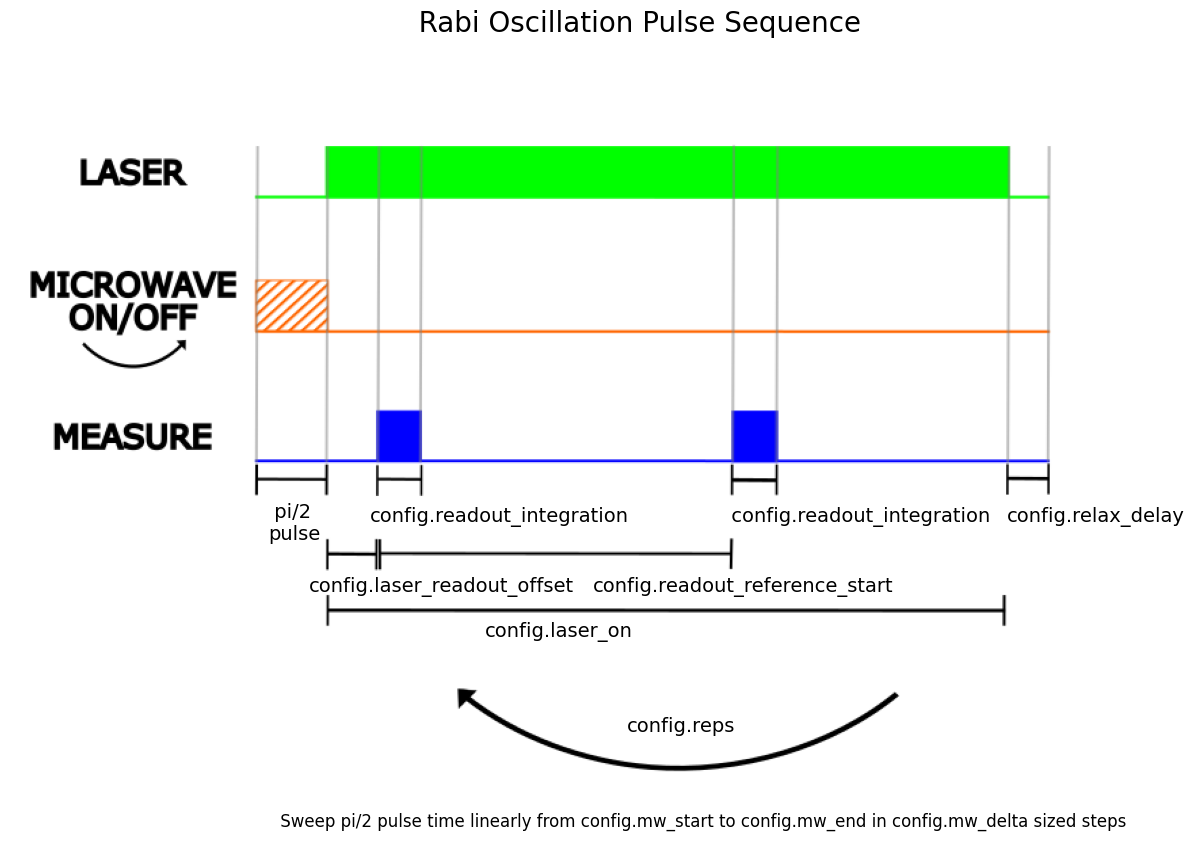

In [15]:
qd.RabiSweep.plot_sequence()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Pulse Length Dependency Test </h3>
</div>



In [11]:
def run_fixed_pulse(mw_length_tns, reps, label):
    config = copy(default_config)

    config.mw_gain = 5000
    config.mw_fMHz = 3440
    config.pre_init = True
    config.relax_delay_treg = 500

    config.laser_on_tus = 15
    config.readout_integration_tns = 50
    config.readout_reference_start_tus = 10
    config.mw_readout_delay_treg = 35
    config.laser_readout_offset_treg = 200

    config.add_linear_sweep('mw', 'tns', start=mw_length_tns, stop=mw_length_tns + 8, delta=8)
    config.reps = reps

    prog = qd.RabiSweep(config)
    d = prog.acquire(progress=True)

    diff = d.signal1 - d.signal2
    print(f"{label}: mean diff = {diff.mean():.1f}, std = {diff.std():.1f}")
    return d

SetPower(70)

d_zero  = run_fixed_pulse(24,   2000000, "near-zero pulse")
d_short = run_fixed_pulse(300,  2000000, "moderate pulse")
d_long  = run_fixed_pulse(3000, 2000000, "long pulse")

Off()


Requested 24 to 32 by 8
Instead using 22.786458333333336 to 29.296875 by 6.510416666666667 in 2 steps


100%|██████████| 4000000/4000000 [02:14<00:00, 29817.99it/s]


near-zero pulse: mean diff = 183.5, std = 10.5

Requested 300 to 308 by 8
Instead using 299.4791666666667 to 305.98958333333337 by 6.510416666666667 in 2 steps


100%|██████████| 4000000/4000000 [02:16<00:00, 29334.92it/s]


moderate pulse: mean diff = -3636.0, std = 699.0

Requested 3000 to 3008 by 8
Instead using 3001.3020833333335 to 3007.8125 by 6.510416666666667 in 2 steps


100%|██████████| 4000000/4000000 [02:37<00:00, 25319.41it/s]


long pulse: mean diff = -6904.5, std = 420.5


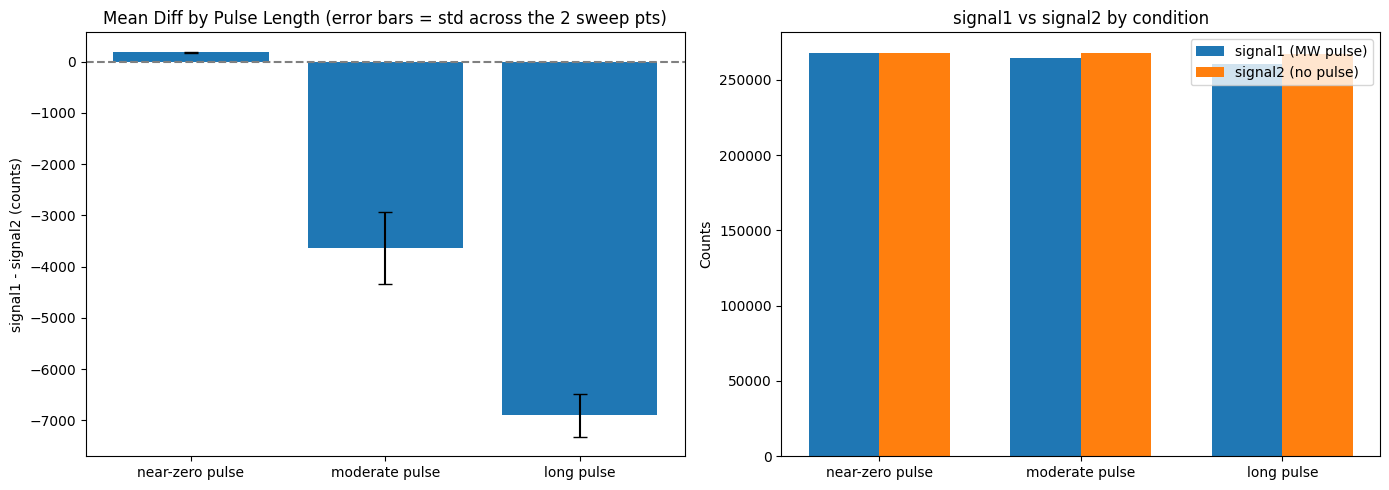

near-zero pulse: mean diff = 183.5, std = 10.5
moderate pulse: mean diff = -3636.0, std = 699.0
long pulse: mean diff = -6904.5, std = 420.5


In [13]:
import numpy as np

labels = ['near-zero pulse', 'moderate pulse', 'long pulse']
results = [d_zero, d_short, d_long]

means = []
stds = []

for d in results:
    diff = d.signal1 - d.signal2
    means.append(diff.mean())
    stds.append(diff.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar plot of mean diff with error bars
axes[0].bar(labels, means, yerr=stds, capsize=5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_ylabel('signal1 - signal2 (counts)')
axes[0].set_title('Mean Diff by Pulse Length (error bars = std across the 2 sweep pts)')

# raw signal1 vs signal2 for each condition, side by side
x = np.arange(len(labels))
width = 0.35

sig1_means = [d.signal1.mean() for d in results]
sig2_means = [d.signal2.mean() for d in results]

axes[1].bar(x - width/2, sig1_means, width, label='signal1 (MW pulse)')
axes[1].bar(x + width/2, sig2_means, width, label='signal2 (no pulse)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Counts')
axes[1].set_title('signal1 vs signal2 by condition')
axes[1].legend()

plt.tight_layout()
plt.show()

for label, mean, std in zip(labels, means, stds):
    print(f"{label}: mean diff = {mean:.1f}, std = {std:.1f}")

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Run Rabi </h3>
</div>



In [ ]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 70
mw_gain = 5000
resonance_fMHz = 3440
sweep_start_tns = 24
sweep_stop_tns = 3000       # ~2 periods based on last run's ~1.5-1.6us period
sweep_step_tns = 60         # fine enough to resolve the oscillation cleanly
reps = 500000

# ---- Setup ----
SetPower(laser_power)

config.mw_gain = mw_gain
config.mw_fMHz = resonance_fMHz
config.pre_init = True
config.relax_delay_treg = 500

config.laser_on_tus = 15
config.readout_integration_tns = 50
config.readout_reference_start_tus = 10
config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 200

config.add_linear_sweep('mw', 'tns', start=sweep_start_tns, stop=sweep_stop_tns, delta=sweep_step_tns)
config.reps = reps

# ---- Run ----
prog = qd.RabiSweep(config)
d = prog.acquire(progress=True)

Off()

# ---- Saving ----
experiment_folder = create_experiment_folder("Rabi")
experiment_id = experiment_folder.name

# ---- Metadata ----
params = {
    "experiment_id": experiment_id,
    "timestamp": datetime.now().isoformat(),
    "laser_power": laser_power,
    "mw_gain": mw_gain,
    "resonance_fMHz": resonance_fMHz,
    "reps": reps,
    "sweep_start_tns": sweep_start_tns,
    "sweep_stop_tns": sweep_stop_tns,
    "sweep_step_tns": sweep_step_tns,
    "relax_delay_treg": config.relax_delay_treg,
    "laser_on_tus": config.laser_on_tus,
    "readout_integration_tns": config.readout_integration_tns,
    "readout_reference_start_tus": config.readout_reference_start_tus,
    "mw_readout_delay_treg": config.mw_readout_delay_treg,
    "laser_readout_offset_treg": config.laser_readout_offset_treg,
}
save_metadata(experiment_folder, params)

# ---- Raw + derived data ----
t = d.sweep_tus
diff = d.signal1 - d.signal2

np.savez(
    experiment_folder / "rabi_data.npz",
    pulse_length_us=t,
    signal1=d.signal1,
    signal2=d.signal2,
    reference1=d.reference1,
    reference2=d.reference2,
    diff=diff,
)

np.savetxt(
    experiment_folder / "rabi_data.csv",
    np.column_stack([t, d.signal1, d.signal2, d.reference1, d.reference2, diff]),
    delimiter=",",
    header="pulse_length_us,signal1,signal2,reference1,reference2,diff",
    comments=""
)

# ---- Plot 1: signal/reference overview ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(t, d.signal1, label='signal1 (MW pulse)')
axes[0].plot(t, d.signal2, label='signal2 (no pulse, reference)')
axes[0].set_xlabel('pulse length (us)')
axes[0].set_ylabel('Counts')
axes[0].set_title(f'Rabi: Raw Signal Counts\n{experiment_id}')
axes[0].legend()

axes[1].plot(t, d.reference1, label='reference1')
axes[1].plot(t, d.reference2, label='reference2')
axes[1].set_xlabel('pulse length (us)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Rabi: Reference Counts (should stay flat)')
axes[1].legend()

axes[2].plot(t, d.contrast)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('pulse length (us)')
axes[2].set_ylabel('Contrast (%)')
axes[2].set_title('Rabi: Contrast')

plt.tight_layout()
fig.savefig(experiment_folder / "rabi_signals_reference.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Plot 2: raw difference ----
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(t, diff)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel('pulse length (us)')
ax2.set_ylabel('signal1 - signal2 (counts)')
ax2.set_title(f'Rabi: Raw Signal Difference\n{experiment_id}')

fig2.savefig(experiment_folder / "rabi_difference.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Experiment saved to: {experiment_folder}")


Requested 24 to 3000 by 60
Instead using 22.786458333333336 to 2893.8802083333335 by 58.59375 in 50 steps


 36%|███▌      | 8923982/25000000 [05:24<09:58, 26840.49it/s]

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Plot Rabi</h3>
</div>



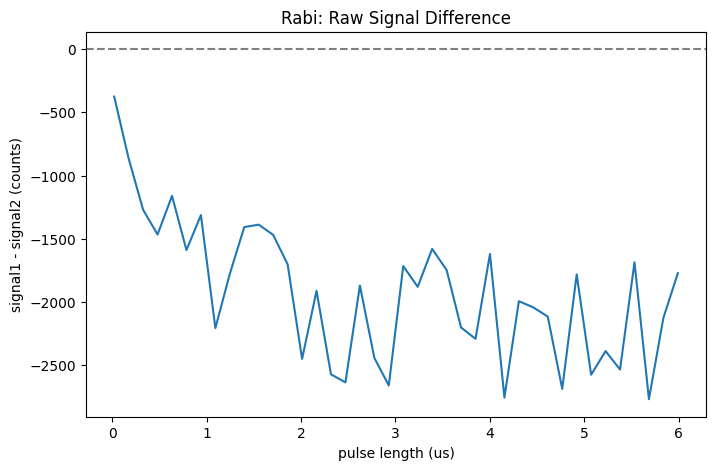

In [16]:
t = d.sweep_tus

diff = d.signal1 - d.signal2

plt.figure(figsize=(8, 5))
plt.plot(t, diff)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('pulse length (us)')
plt.ylabel('signal1 - signal2 (counts)')
plt.title('Rabi: Raw Signal Difference')
plt.show()

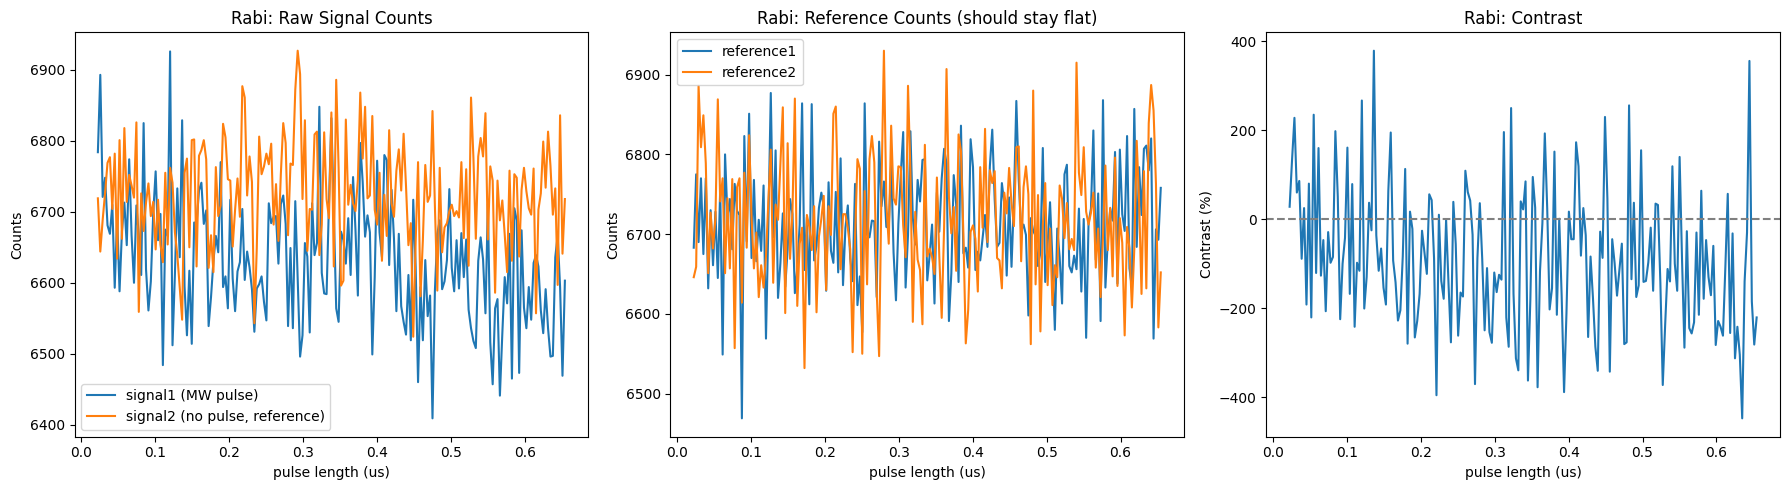

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t = d.sweep_tus

axes[0].plot(t, d.signal1, label='signal1 (MW pulse)')
axes[0].plot(t, d.signal2, label='signal2 (no pulse, reference)')
axes[0].set_xlabel('pulse length (us)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Rabi: Raw Signal Counts')
axes[0].legend()

axes[1].plot(t, d.reference1, label='reference1')
axes[1].plot(t, d.reference2, label='reference2')
axes[1].set_xlabel('pulse length (us)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Rabi: Reference Counts (should stay flat)')
axes[1].legend()

axes[2].plot(t, d.contrast)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('pulse length (us)')
axes[2].set_ylabel('Contrast (%)')
axes[2].set_title('Rabi: Contrast')

plt.tight_layout()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Fit Rabi </h3>
</div>



In [ ]:
def decaying_cos(x, A, T, tau):

    return -A /2 * (np.cos(x*2*np.pi/T- np.pi))*np.exp(-x/tau) - A/2

In [ ]:
p0 = [-40000, 0.3, 0.5]

t = d.sweep_tus
x = d.contrast

param, _ = curve_fit(decaying_cos, t, x, p0 = p0)

plt.plot(d.sweep_tus, d.contrast)

plt.plot(t, decaying_cos(t, *param), linewidth=4)
plt.ylabel('Difference')
plt.xlabel('time (us)')
plt.xlim(0, np.max(t))
plt.ylim(np.min(x), 0)
print('Pi/2 pulse is approximately {:.0f} ns'.format(param[1]*1000/4))
plt.vlines(param[1]/4, np.min(d.contrast), 0)



# 6 Ramsey <a class="anchor" id="seventh-bullet"></a>
Now that we have the pumping time from our inital spin state to m<sub>s</sub>=0, we want to measure the transition frequency and T2<sup>*</sup>. Specifically, to measure the transition frequency and T2<sup>*</sup> we perform a Ramsey pulse sequence and then use a Real-Valued Fast Fourier Transform (RFFT) to extract the transition frequency from the signal. Ramsey avoids the power broadening of optically detected magnetic resonace (ODMR)) and gives a view of the spectrum given that the pi/2 pulse is sufficeint to excite the whole spectrum.

In [ ]:
qd.Ramsey.plot_sequence()

## 6a. Configuration, Measurement, and Plotting
Ramsey pulse sequence adds the following new settings to the configuration:

- .delay_start_t#- ldelay length the sweep begins at 
- .delay_end_t# - delay length the sweep ends at
- .nsweep_points - the number of points in the sweep 



In [ ]:
config = copy(default_config)

config.mw_gain = 30000
config.mw_fMHz = 2768 - 3 #pulse slightly off resonant frequency
config.mw_pi2_tns = 100

config.relax_delay_tus = 0.5
config.pre_init = True

config.mw_readout_delay_treg = 35 #
config.laser_readout_offset_treg= 150 #

config.laser_on_tus = 15 # in us
config.readout_integration_tus = 2 # us
config.readout_reference_start_tus = 12 # us

#for linear delay sweep
config.add_linear_sweep('delay', 'treg', 8, 800, 100)
config.nsweep_points=100

config.reps=10000

prog = qd.Ramsey(config)
d = prog.acquire(progress=True)




In [ ]:
t = d.sweep_tus
x = d.contrast

# param, _ = curve_fit(qd.exponential_decay, t, x, p0 = p0)

plt.plot(t, x)

plt.ylabel('Contrast (%)')
plt.xlabel('Delay time (us)')

plt.xlim(np.min(t), np.max(t))
plt.ylim(np.min(x), np.max(x))

plt.title('Ramsey Delay Sweep')

plt.show()


In [ ]:
t = d.sweep_tus
x = d.contrast


fs = config.nsweep_points/(config.delay_end_tus-config.delay_start_tus)  # Sampling frequency

# Perform the Fast Fourier Transform (FFT)
fft_result = np.fft.rfft(x)
frequencies_fft = np.fft.rfftfreq(len(fft_result), 1/fs)
plt.ylabel("Intensity")
plt.xlabel("Frequency MHz")
plt.title('Ramsey Delay Sweep RFFT')
plt.plot(np.abs(fft_result))



In [ ]:
qd.Ramsey.plot_sequence(config)


# 7 Hahn Echo Delay Sweep <a class="anchor" id="eigth-bullet"></a>
With the calibraiton of our pi/2 pulse from our Rabi Oscillation data, we can now move on to measuring properties of our NV enviroment, first, by measuring the Hahn Echo T<sub>2,Hahn</sub>.  In our Hahn echo pulse sequence, we have two pulse sequences and four readouts, just as before.  In the first pulse sequence, we exectue microwave pi/2 - delay - pi - delay - pi/2 followed by our readout window.  In the second pulse sequence, we exectue the microwave sequence pi/2 - delay - pi - delay - pi/2<sub>-x</sub> followd by our readout window. These sequences project the NV spin state on to the -z and +z axes of the Bloch sphere, giving contrast between projected spin states.

In [ ]:
qd.HahnEchoDelaySweep.plot_sequence()

## 7a. Configuration, Measurement, and Plotting

The configuration attributes for the Hahn Echo T<sub>2</sub> pulse sequence are quite similar to those of the Rabi Oscillations.  The main change here is the addition of sweep parameters that scale exponentially. These are assigned by the NVConfiguration.add_exponential_sweep() method with parameters 
- swept parameter name : 'delay'
- swept parameter unit: 'tus'
- start value : 0.05
- stop value : 50
- scaling_factor : '17/16'

These parameters generate a sweep that changes the delay time (in us) from 0.05 us to 50 us, where the steps are delay<sub>i+1</sub> = 17/16 x delay<sub>i</sub> starting at  0.05 us until the final delay is the first value larger than 50us. The cell below is an example of both how to configure  qd.HahnEchoDelaySweep and acquire the data

In [ ]:
config = copy(default_config)

config.mw_gain = 30000
config.mw_fMHz = 2768
config.mw_pi2_tns = 100

config.relax_delay_tus = 0.5
config.pre_init=True

config.mw_readout_delay_treg = 35 #
config.laser_readout_offset_treg= 150 #

config.laser_on_tus = 15 # in us
config.readout_integration_tus = 2 # us
config.readout_reference_start_tus = 12 # us

config.add_exponential_sweep('delay', 'tus', start=0.05, stop=50, scaling_factor='9/8')

config.reps=10000

prog = qd.HahnEchoDelaySweep(config)
d = prog.acquire(progress=True)


q.HahnEchoDelaySweep.acquire() returns a data object with attributes, sweep_tus, sweep_tns, sweep_treg, singal1, signal2, reference1, reference2, contrast1, contrast2, and contrast.  All of which we have seen before from our qd.RabiOscillation.acquire() method. 

In [ ]:
t = d.sweep_tus
x = d.contrast

# param, _ = curve_fit(qd.exponential_decay, t, x, p0 = p0)

plt.plot(t, x)
plt.xscale('log')

plt.ylabel('Contrast (counts)')
plt.xlabel('Delay time (us)')

plt.xlim(np.min(d.sweep_tus), np.max(d.sweep_tus))
plt.ylim(np.min(d.contrast), np.max(d.contrast))

plt.title('Hahn Echo Delay Sweep Results')

plt.show()


In [ ]:
qd.HahnEchoDelaySweep.plot_sequence(config)

# 8. T<sub>1</sub> Delay Sweep <a class="anchor" id="nineth-bullet"></a>

The spin lattice relaxation time is another fundamental parameter of our NVs that we want to measure either to characterize our NVs or a material of interest close to the NVs. Our T<sub>1</sub> pulse sequence consists of initializing the spins to m<sub>s</sub> = 0, followed by a microwave pulse (or none for referencing) and a variable delay time, then a readout. There are a total of four measurements in this pulse sequence "signal1" at the beginning of the first readout window where have inverted the spins, "reference1" toward the end of the readout window, "signal2" at the beginning of the second readout window where we have not inverted the spins, and "reference2" toward the end of the second readout window. 

In [ ]:
qd.T1DelaySweep.plot_sequence()

## 8a. Configuration, Measurement, and Plotting

Configuration attributes for qd.T1DelaySweep are identical to that of qd.HahnEchoDelaySweep, however in this example we alter the start, stop and scaling factor of the delay so that we can acquire the full T1 relaxation curve, which can last up to a few ms for NVs at room temperature.  The cell below is an example configuration and acquisition with the T<sub>1</sub> Delay Sweep program

In [ ]:
# exponential scaling

config = copy(default_config)

config.mw_gain = 30000
config.mw_fMHz = 2768
config.mw_pi2_tns = 100

config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 150
config.relax_delay_treg = 20

config.pre_init=True

config.laser_on_tus = 15 # in us
config.readout_integration_tus = 2 # us
config.readout_reference_start_tus = 12 # us

config.add_exponential_sweep('delay', 'tus', start=0.5, stop=20000, scaling_factor='3/2')

config.reps=5000

prog = qd.T1DelaySweep(config)
d = prog.acquire(progress=True)


In [ ]:
p0 = [3000, 5e3]

t = d.sweep_tus
x = d.contrast

fit_func = lambda t, a, tau: qd.exponential_decay(t, a, tau, 0)
plt.plot(t, x)
plt.plot(t, fit_func(t, *p0))

param, _ = curve_fit(fit_func, t, x, p0)
plt.plot(t, fit_func(d.sweep_tus, *param))

plt.xscale('log')
print('T1 is approximately {:0f} ms'.format(param[1]/1e3))
plt.title('T1 Relaxation')
plt.ylabel('Contrast (%)')
plt.xlabel('Delay (us)')
plt.show()

In [ ]:
qd.T1DelaySweep.plot_sequence(config)


As of January 2025, this concludes our Demo Notebook for QICK-DAWG.  We have shown how to configure measurements, collect data, and have demonstrated fundatmental pulse sequences for NV magnetometry.  In the future, we plan on adding
- A demo for CPMGXY8-n
- and more!